In [3]:
import pandas as pd
import numpy as np
import glob
import os
from pandas.api.types import is_integer_dtype, is_float_dtype
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. MERGE DATA ---")
path = './CIC-IDS2017_Data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

# Đọc và sau đó gộp tất cả các file CSV lại thành 1 DataFrame
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

print(f"[+] Đã gộp thành công {len(all_files)} files.")
print(f"[+] Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột.")

--- 1. MERGE DATA ---
[+] Đã gộp thành công 8 files.
[+] Kích thước ban đầu: 2830743 dòng, 79 cột.


In [4]:
print("--- 2. DATA CLEANING ---")

# 1. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()
print("[+] Đã xóa khoảng trắng ở tên cột.")

# 2. Xóa các dòng trùng lặp (Duplicate rows)
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"[+] Đã xóa {initial_rows - len(df)} dòng trùng lặp.")

# 3. Xử lý Inf và NaN bằng cách thay thế bằng Median (Trung vị)
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Biến đổi Inf thành NaN để dễ xử lý đồng loạt
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print("[+] Đang tính toán và thay thế giá trị NaN/Inf bằng Median...")
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
print("[+] Đã xử lý xong Inf và NaN.")

# 4. Xóa các cột có phương sai bằng 0
variances = df[numeric_cols].var()
zero_var_cols = variances[variances == 0].index
df.drop(columns=zero_var_cols, inplace=True)
print(f"[+] Đã xóa {len(zero_var_cols)} cột có phương sai bằng 0: {list(zero_var_cols)}")



--- 2. DATA CLEANING ---
[+] Đã xóa khoảng trắng ở tên cột.
[+] Đã xóa 308381 dòng trùng lặp.
[+] Đang tính toán và thay thế giá trị NaN/Inf bằng Median...
[+] Đã xử lý xong Inf và NaN.
[+] Đã xóa 8 cột có phương sai bằng 0: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [5]:
print("--- 3. MEMORY OPTIMIZATION ---")

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"[*] RAM sử dụng ban đầu: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
                
        elif is_float_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
                
        else:
            # Nếu là object hoặc dạng khác, ép về category để tiết kiệm RAM
            df[col] = df[col].astype('category')
        
        print(f"    - {col}: {col_type} -> {df[col].dtype}")

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"[+] RAM sử dụng sau tối ưu: {end_mem:.2f} MB")
    print(f"[+] Đã giảm được {100 * (start_mem - end_mem) / start_mem:.1f}% dung lượng RAM!")
    return df

df = reduce_mem_usage(df)


--- 3. MEMORY OPTIMIZATION ---
[*] RAM sử dụng ban đầu: 1385.57 MB
    - Destination Port: int64 -> int32
    - Flow Duration: int64 -> int32
    - Total Fwd Packets: int64 -> int32
    - Total Backward Packets: int64 -> int32
    - Total Length of Fwd Packets: int64 -> int32
    - Total Length of Bwd Packets: int64 -> int32
    - Fwd Packet Length Max: int64 -> int16
    - Fwd Packet Length Min: int64 -> int16
    - Fwd Packet Length Mean: float64 -> float32
    - Fwd Packet Length Std: float64 -> float32
    - Bwd Packet Length Max: int64 -> int16
    - Bwd Packet Length Min: int64 -> int16
    - Bwd Packet Length Mean: float64 -> float32
    - Bwd Packet Length Std: float64 -> float32
    - Flow Bytes/s: float64 -> float32
    - Flow Packets/s: float64 -> float32
    - Flow IAT Mean: float64 -> float32
    - Flow IAT Std: float64 -> float32
    - Flow IAT Max: int64 -> int32
    - Flow IAT Min: int64 -> int32
    - Fwd IAT Total: int64 -> int32
    - Fwd IAT Mean: float64 -> float32

--- 4. EXPLORATORY DATA ANALYSIS (EDA) ---


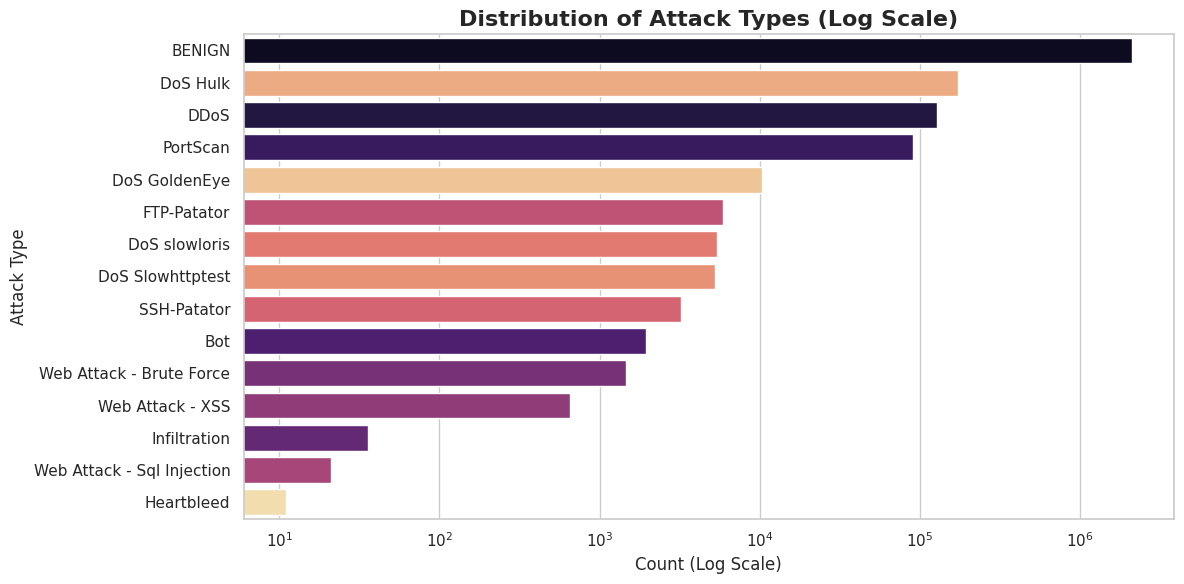

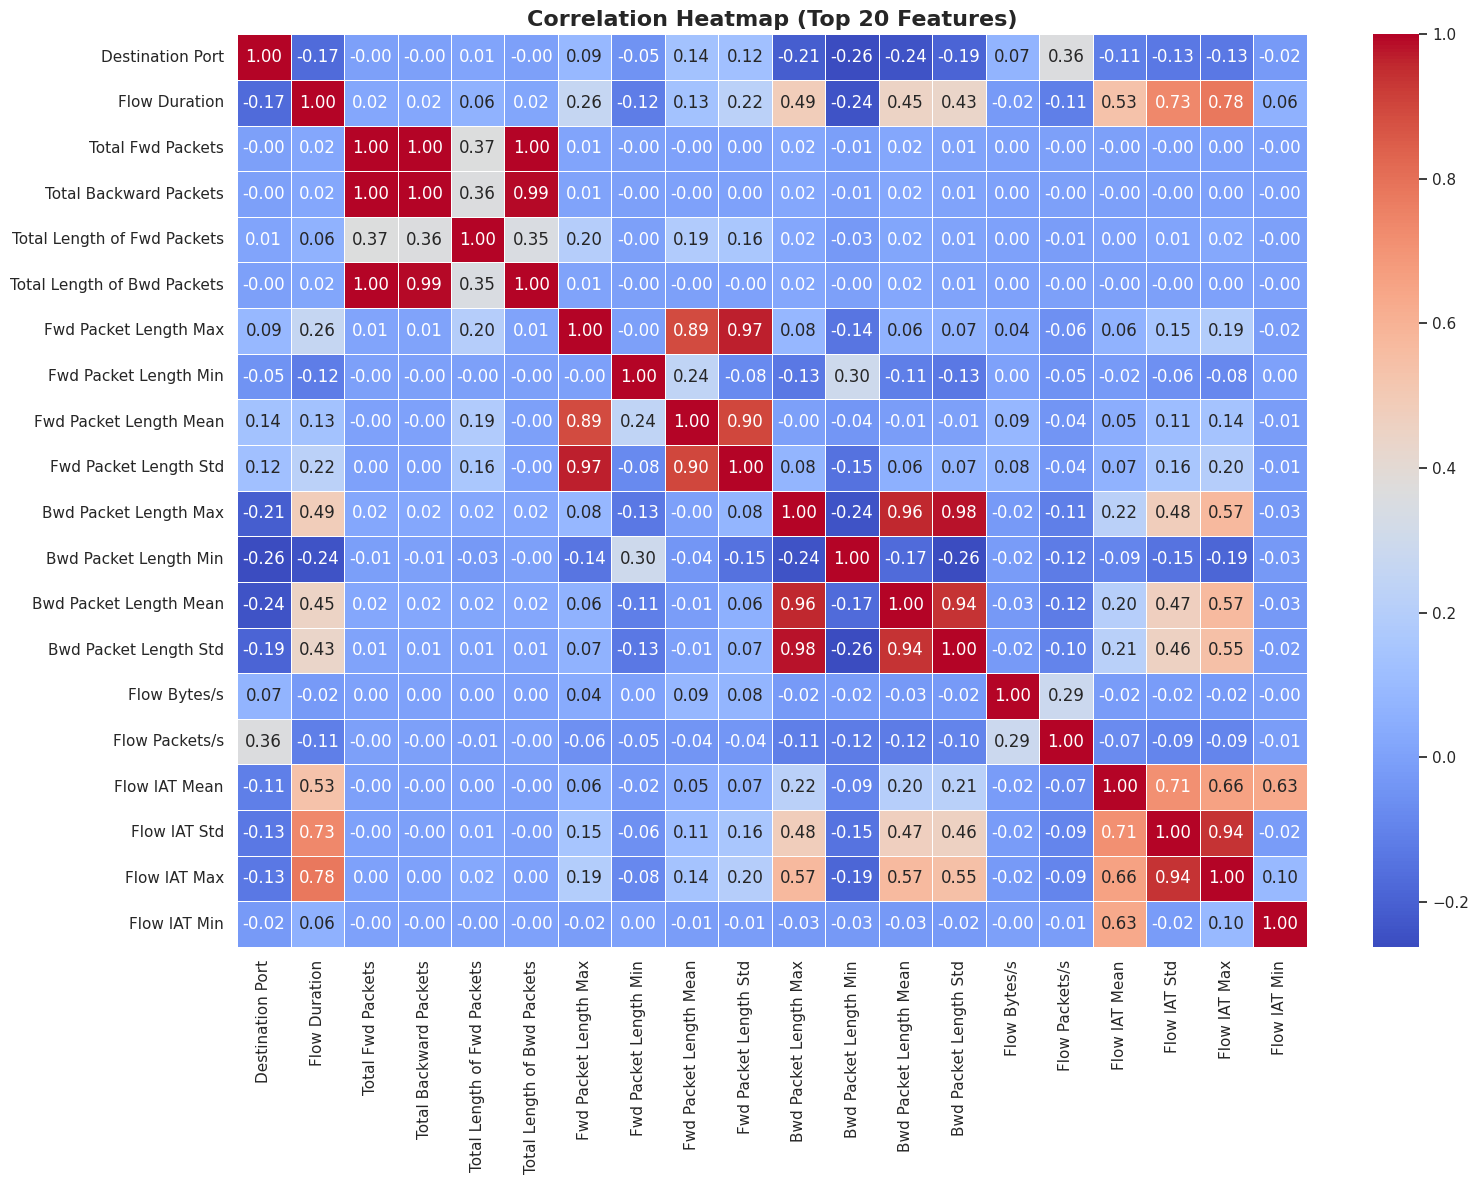

In [ ]:
print("--- 4. EXPLORATORY DATA ANALYSIS (EDA) ---")
sns.set_theme(style="whitegrid")

df['Label'] = df['Label'].astype(str).str.replace(r'[^\x00-\x7F]+', '-', regex=True)

plt.rcParams['font.family'] = 'DejaVu Sans'

# Biểu đồ 1: Phân phối các loại tấn công
plt.figure(figsize=(12, 6))
order = df['Label'].value_counts().index

sns.countplot(y="Label", data=df, order=order, hue="Label", palette="magma", legend=False)
plt.title('Distribution of Attack Types (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.xscale('log') 
plt.tight_layout()
plt.show()

# Biểu đồ 2: Correlation Heatmap
plt.figure(figsize=(16, 12))
numeric_features = df.select_dtypes(include=[np.number])
corr_matrix = numeric_features.iloc[:, :20].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Top 20 Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()